In [15]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from Ranking_exp import Ranking_exp

In [16]:
dummy_df = pd.DataFrame({
    'rank_higher': [0, 1, 2],
    'rank_lower': [1, 2, 0],
    'seed': [42, 42, 42],
    'metric1': [0.5, 0.7, 0.2],
    'is_train': [True, False, True],
    'is_exception': [False, True, False]
})


def _build_matrix(sub: pd.DataFrame, metric: str):
    agg = (
        sub.groupby(["rank_higher", "rank_lower", "seed"])[metric].mean()
        .reset_index()
        .groupby(["rank_higher", "rank_lower"])[metric].mean()
        .reset_index()
    )
    meta = (
        sub.groupby(["rank_higher", "rank_lower"])[["is_train", "is_exception"]]
        .first()
        .reset_index()
    )
    agg = agg.merge(meta, on=["rank_higher", "rank_lower"])
    n = int(agg[["rank_higher", "rank_lower"]].max().max()) + 1
    M          = np.full((n, n), np.nan)
    train_mask = np.zeros((n, n), dtype=bool)
    exc_mask   = np.zeros((n, n), dtype=bool)
    for _, row in agg.iterrows():
        i, j = int(row["rank_higher"]), int(row["rank_lower"])
        M[i, j] = row[metric]
        if row["is_train"] and not row["is_exception"]:
            train_mask[i, j] = True
        if row["is_exception"]:
            exc_mask[i, j] = True
    return M, train_mask, exc_mask


def _draw_matrix(ax, M, train_mask, exc_mask, *, cmap, vmin, vmax, fmt,
                 tick_labels=None, show_numbers=False, colorbar_label=""):
    n = M.shape[0]
    im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal", interpolation="nearest")
    cb = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.03, fraction=0.046)
    cb.set_label(colorbar_label, fontsize=6)
    cb.ax.tick_params(labelsize=5)

    if show_numbers:
        for i in range(n):
            for j in range(n):
                if not np.isnan(M[i, j]):
                    ax.text(j, i, f"{M[i, j]:{fmt}}", ha="center", va="center",
                            fontsize=5, color="black")

    for i in range(n):
        for j in range(n):
            if train_mask[i, j]:
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                             fill=False, edgecolor="black", lw=1.5, zorder=3))
            elif exc_mask[i, j]:
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                             fill=False, edgecolor="darkorange", lw=1.5, zorder=3))

    labels = tick_labels if tick_labels is not None else [str(k + 1) for k in range(n)]
    ax.set_xticks(range(n))
    ax.set_xticklabels(labels, fontsize=6)
    ax.set_yticks(range(n))
    ax.set_yticklabels(labels, fontsize=6)
    ax.set_xlabel("Lower rank", fontsize=6, labelpad=2)
    ax.set_ylabel("Higher rank", fontsize=6, labelpad=2)
    ax.tick_params(axis="both", length=2, pad=1)


def plot_setting_heatmaps(sub: pd.DataFrame, title: str, tick_labels=None,
                          phase: str = "post", show: str = "both",
                          show_numbers: bool = False):
    """
    show: "margin" | "accuracy" | "both"
    show_numbers: annotate each cell with its value
    """
    sub = sub[sub["phase"] == phase].copy()
    if sub.empty:
        return

    n      = int(sub[["rank_higher", "rank_lower"]].max().max()) + 1
    ncols  = 2 if show == "both" else 1
    cell_w = max(0.5, n * 0.1)
    cell_h = max(0.5, n * 0.1)
    fig, axes = plt.subplots(1, ncols,
                             figsize=(cell_w * ncols + ncols * 0.9, cell_h + 0.5),
                             squeeze=False)
    axes = axes[0]

    ax_idx = 0
    if show in ("margin", "both"):
        M_m, tm, em = _build_matrix(sub, "margin")
        ext = max(abs(np.nanmax(M_m)), abs(np.nanmin(M_m)), 0.1)
        _draw_matrix(axes[ax_idx], M_m, tm, em,
                     cmap="bwr_r", vmin=-ext, vmax=ext, fmt="+.2f",
                     tick_labels=tick_labels, show_numbers=show_numbers,
                     colorbar_label="Margin")
        ax_idx += 1

    if show in ("accuracy", "both"):
        M_a, ta, ea = _build_matrix(sub, "correct")
        _draw_matrix(axes[ax_idx], M_a * 100, ta, ea,
                     cmap="bwr_r", vmin=0.0, vmax=100.0, fmt=".0f",
                     tick_labels=tick_labels, show_numbers=show_numbers,
                     colorbar_label="Accuracy (%)")

    fig.suptitle(title, fontsize=6, y=1.02)
    plt.tight_layout(pad=0.5, w_pad=0.8)
    plt.show()

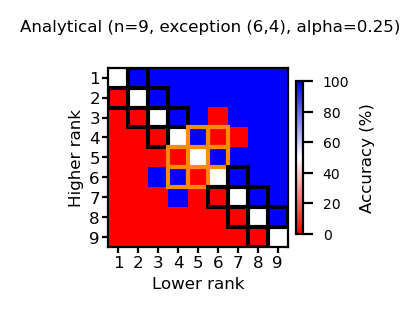

In [17]:
import contextlib, io

n     = 9
p     = 6
q     = 4
alpha = 0.25

k_s = 1.0
k_d = 0.0
k_o = ((1 - alpha) / 2) * (k_s - k_d)

c_reg = 1e10

with contextlib.redirect_stdout(io.StringIO()):
    sim = Ranking_exp(n=n, k_o=k_o, k_s=k_s, k_d=k_d,
                      p=p, q=q, c_reg=c_reg)

rows = []
for i in range(n):
    for j in range(n):
        if i == j:
            continue
        margin = sim.f_j_k(i + 1, j + 1)
        is_exception = ((i == p - 1 and j == q - 1) or
                        (i == q - 1 and j == p - 1))
        transverse_pairs = (i, j) in [(q-1, p-1), (q-1, q), (q, q+1)] or (i, j) in [(p-1, q-1), (p-1, q), (p-2, q-1)]
        is_train         = (i == j + 1) or (j == i + 1) or transverse_pairs
        rows.append({
            "phase":        "post",
            "seed":         0,
            "rank_higher":  i,
            "rank_lower":   j,
            "margin":       margin,
            "correct":      1 if margin > 0 else 0,
            "is_train":     is_train,
            "is_exception": transverse_pairs,
        })

df = pd.DataFrame(rows)

with plt.rc_context({'figure.dpi': 200}): #only for ipynb
    plot_setting_heatmaps(
        df,
        title=f"Analytical (n={n}, exception ({p},{q}), alpha={alpha})",
        show="accuracy"
    )

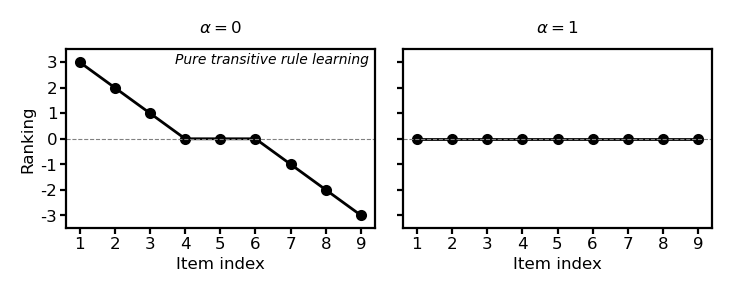

In [ ]:
import contextlib, io

n     = 9
p     = 6
q     = 4

k_s   = 1.0
k_d   = 0.0
c_reg = 1e10

eps          = 1e-10
alphas       = [0, 1 - eps]
panel_labels = [r'$\alpha = 0$', r'$\alpha = 1$']
           

x = np.arange(1, n + 1)

with plt.rc_context({'figure.dpi': 200}):
    fig, axes = plt.subplots(1, 2, figsize=(3.6, 1.4), sharey=True)

    for ax, a, lbl in zip(axes, alphas, panel_labels):
        k_o_a = ((1 - a) / 2) * (k_s - k_d)
        with contextlib.redirect_stdout(io.StringIO()):
            sim_a = Ranking_exp(n=n, k_o=k_o_a, k_s=k_s, k_d=k_d,
                                p=p, q=q, c_reg=c_reg)
        r = sim_a.calc_rank_analytic()
        ax.plot(x, r, marker='o', markersize=3, lw=1.0, color='black')
        ax.axhline(0, color='gray', lw=0.4, ls='--')
        ax.set_xticks(x)
        ax.set_xticklabels([str(k) for k in x], fontsize=6)
        ax.set_ylim(-3.5, 3.5)
        ax.set_yticks(np.arange(-3, 4, 1))
        ax.set_yticklabels([str(k) for k in np.arange(-3, 4, 1)], fontsize=6)
        ax.set_xlabel('Item index', fontsize=6, labelpad=2)
        ax.set_title(lbl, fontsize=6)
        ax.tick_params(axis='both', length=2, pad=1, labelsize=6)

    axes[0].set_ylabel('Ranking', fontsize=6, labelpad=2)
    axes[0].text(0.98, 0.98, 'Pure transitive rule learning', transform=axes[0].transAxes,
                 fontsize=5, ha='right', va='top', style='italic')
            
    plt.tight_layout(pad=0.5, w_pad=0.8)
    plt.show()

fig.savefig("Figure 4.2a.pdf", dpi=300, bbox_inches='tight')

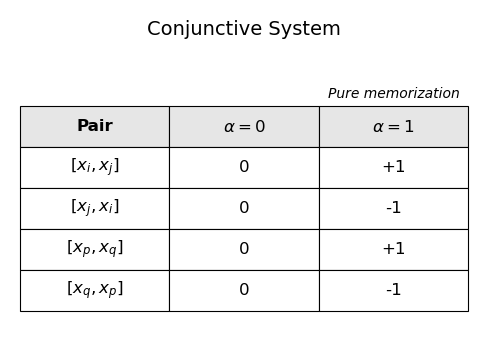

In [41]:
import contextlib, io

n     = 9
p     = 6
q     = 4

k_s   = 1.0
k_d   = 0.0
c_reg = 1e10

eps          = 1e-10
alphas       = [0, 1 - eps]
alpha_labels = [r'$\alpha = 0$', r'$\alpha = 1$']

pairs = [
    (1, 2,   r'$[x_i, x_j]$'),
    (2, 1,   r'$[x_j, x_i]$'),
    (p, q,   r'$[x_p, x_q]$'),
    (q, p,   r'$[x_q, x_p]$'),
]

sims = []
for a in alphas:
    k_o_a = ((1 - a) / 2) * (k_s - k_d)
    with contextlib.redirect_stdout(io.StringIO()):
        sim_a = Ranking_exp(n=n, k_o=k_o_a, k_s=k_s, k_d=k_d,
                            p=p, q=q, c_reg=c_reg)
    sims.append(sim_a)

col_labels = ['Pair'] + alpha_labels
cell_text = []
for (j, k, pair_label) in pairs:
    row = [pair_label]
    for idx, sim_a in enumerate(sims):
        margin = sim_a.f_j_k(j, k)
        if idx == 0:
            row.append('0')
        else:
            row.append(f'{round(margin):+d}')
    cell_text.append(row)

with plt.rc_context({'figure.dpi': 200}):
    fig, ax = plt.subplots(1, 1, figsize=(2.4, 1.7))
    ax.axis('off')

    tbl = ax.table(cellText=cell_text, colLabels=col_labels,
                   loc='center', cellLoc='center')
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(6)
    tbl.scale(1.0, 1.3)
    for (row, col), cell in tbl.get_celld().items():
        cell.set_linewidth(0.4)
        if row == 0:
            cell.set_text_props(fontweight='bold', fontsize=6)
            cell.set_facecolor('#e6e6e6')
        else:
            cell.set_facecolor('white')

    fig.canvas.draw()
    alpha1_cell = tbl[0, 2]
    bbox = alpha1_cell.get_bbox().transformed(ax.transData)
    bbox_ax = ax.transAxes.inverted().transform(bbox)
    cx = (bbox_ax[0][0] + bbox_ax[1][0]) / 2
    top_y = bbox_ax[1][1]
    ax.text(cx, top_y + 0.02, 'Pure memorization', transform=ax.transAxes,
            fontsize=5, ha='center', va='bottom', style='italic')
    ax.set_title("Conjunctive System", fontsize=7, pad=18)

    plt.tight_layout(pad=0.5)
    plt.show()

fig.savefig("Figure 4.2b.pdf", dpi=300, bbox_inches='tight')

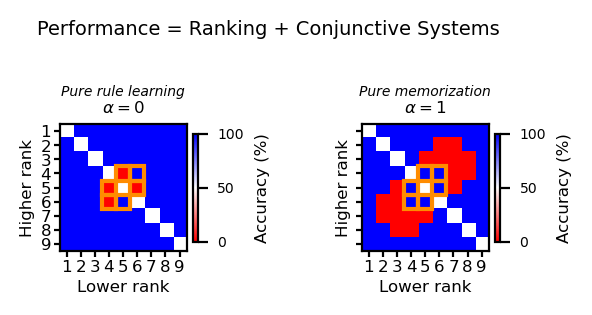

In [39]:
import contextlib, io

n     = 9
p     = 6
q     = 4

k_s   = 1.0
k_d   = 0.0
c_reg = 1e10

eps    = 1e-10
alphas = [0, 1 - eps]

expected = np.full((n, n), np.nan)
for i in range(n):
    for j in range(n):
        if i != j:
            expected[i, j] = 1.0 if i < j else -1.0
expected[5, 3] = 1.0
expected[3, 5] = -1.0

computed = []
for a in alphas:
    k_o_a = ((1 - a) / 2) * (k_s - k_d)
    with contextlib.redirect_stdout(io.StringIO()):
        sim_a = Ranking_exp(n=n, k_o=k_o_a, k_s=k_s, k_d=k_d,
                            p=p, q=q, c_reg=c_reg)
    M = np.full((n, n), np.nan)
    for i in range(n):
        for j in range(n):
            if i != j:
                M[i, j] = sim_a.f_j_k(i + 1, j + 1)
    computed.append(M)

exc_mask = np.zeros((n, n), dtype=bool)
for i in range(n):
    for j in range(n):
        transverse_pairs = ((i, j) in [(q-1, p-1), (q-1, q), (q, q+1)] or
                            (i, j) in [(p-1, q-1), (p-1, q), (p-2, q-1)])
        if transverse_pairs:
            exc_mask[i, j] = True

def draw_accuracy_panel(ax, margins, expected_signs, title, exc_mask=None):
    accuracy = np.full_like(margins, np.nan)
    mask = ~np.isnan(margins)
    accuracy[mask] = (np.sign(margins[mask]) == np.sign(expected_signs[mask])) * 100

    im = ax.imshow(accuracy, cmap='bwr_r', vmin=0.0, vmax=100.0,
                   aspect='equal', interpolation='nearest')
    cb = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.03, fraction=0.046)
    cb.set_label('Accuracy (%)', fontsize=6)
    cb.ax.tick_params(labelsize=5)

    if exc_mask is not None:
        for i in range(n):
            for j in range(n):
                if exc_mask[i, j]:
                    ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                                 fill=False, edgecolor='darkorange', lw=1.5, zorder=3))

    ax.set_xticks(range(n))
    ax.set_xticklabels([str(k + 1) for k in range(n)], fontsize=6)
    ax.set_yticks(range(n))
    ax.set_yticklabels([str(k + 1) for k in range(n)], fontsize=6)
    ax.set_xlabel('Lower rank', fontsize=6, labelpad=2)
    ax.set_ylabel('Higher rank', fontsize=6, labelpad=2)
    ax.tick_params(axis='both', length=2, pad=1, labelsize=6)
    ax.set_title(title, fontsize=6, pad=4)

with plt.rc_context({'figure.dpi': 200}):
    fig, axes = plt.subplots(1, 2, figsize=(3.2, 1.4), sharey=True)

    draw_accuracy_panel(axes[0], computed[0], expected, r'$\alpha = 0$', exc_mask)
    draw_accuracy_panel(axes[1], computed[1], expected, r'$\alpha = 1$', exc_mask)

    axes[0].text(0.5, 1.20, 'Pure rule learning', transform=axes[0].transAxes,
                 fontsize=5, ha='center', va='bottom', style='italic')
    axes[1].text(0.5, 1.20, 'Pure memorization', transform=axes[1].transAxes,
                 fontsize=5, ha='center', va='bottom', style='italic')

    fig.suptitle('Performance = Ranking + Conjunctive Systems', fontsize=7, y=1.02)
    plt.tight_layout(pad=0.5, w_pad=0.2)
    plt.show()

fig.savefig("Figure 4.2c.pdf", dpi=300, bbox_inches='tight')

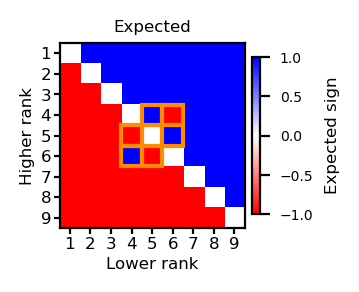

In [35]:
with plt.rc_context({'figure.dpi': 200}):
    fig, ax = plt.subplots(1, 1, figsize=(1.8, 1.4))

    im = ax.imshow(expected, cmap='bwr_r', vmin=-1.0, vmax=1.0,
                   aspect='equal', interpolation='nearest')
    cb = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.03, fraction=0.046)
    cb.set_label('Expected sign', fontsize=6)
    cb.ax.tick_params(labelsize=5)

    for i in range(n):
        for j in range(n):
            if exc_mask[i, j]:
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1,
                             fill=False, edgecolor='darkorange', lw=1.5, zorder=3))

    ax.set_xticks(range(n))
    ax.set_xticklabels([str(k + 1) for k in range(n)], fontsize=6)
    ax.set_yticks(range(n))
    ax.set_yticklabels([str(k + 1) for k in range(n)], fontsize=6)
    ax.set_xlabel('Lower rank', fontsize=6, labelpad=2)
    ax.set_ylabel('Higher rank', fontsize=6, labelpad=2)
    ax.tick_params(axis='both', length=2, pad=1, labelsize=6)
    ax.set_title('Expected', fontsize=6, pad=4)

    plt.tight_layout(pad=0.5)
    plt.show()

In [ ]:
import contextlib, io
from matplotlib.colors import ListedColormap

n     = 9
p     = 6
q     = 4

k_s   = 1.0
k_d   = 0.0
c_reg = 1e10

eps          = 1e-10
alphas       = [eps]

# Build expected margin matrix: +1 if i ranks higher than j, -1 otherwise
expected = np.full((n, n), np.nan)
for i in range(n):
    for j in range(n):
        if i != j:
            expected[i, j] = 1.0 if i < j else -1.0
# Exception pair: item at index 5 ranks higher than item at index 3
expected[5, 3] = 1.0
expected[3, 5] = -1.0

# Build computed margin matrices for alpha=0 and alpha=1
computed = []
for a in alphas:
    k_o_a = ((1 - a) / 2) * (k_s - k_d)
    with contextlib.redirect_stdout(io.StringIO()):
        sim_a = Ranking_exp(n=n, k_o=k_o_a, k_s=k_s, k_d=k_d,
                            p=p, q=q, c_reg=c_reg)
    M = np.full((n, n), np.nan)
    for i in range(n):
        for j in range(n):
            if i != j:
                M[i, j] = sim_a.f_j_k(i + 1, j + 1)
    computed.append(M)

print(M)


[[        nan  1.          2.          3.          3.          3.
   4.00000018  4.99999987  6.00000014]
 [-1.                 nan  1.          2.          2.          2.
   3.00000018  3.99999987  5.00000014]
 [-2.         -1.                 nan  1.          1.          1.
   2.00000018  2.99999987  4.00000015]
 [-2.99999999 -2.         -0.99999999         nan  0.5        -0.5
   1.00000019  1.99999988  3.00000015]
 [-3.         -2.         -1.         -0.5                nan  0.5
   1.          2.          3.        ]
 [-3.         -2.         -1.00000001  0.5        -0.5                nan
   1.00000018  1.99999987  3.00000015]
 [-3.99999987 -2.99999987 -1.99999988 -0.99999952 -0.99999952 -0.99999952
          nan  1.          2.00000027]
 [-5.00000014 -4.00000015 -3.00000015 -2.00000048 -2.00000048 -2.00000048
  -0.99999997         nan  1.        ]
 [-5.99999989 -4.99999989 -3.99999989 -3.         -3.         -3.
  -1.99999971 -1.00000002         nan]]


In [ ]:
sim_a.f_j_k(4,5) #error in this code?  

np.float64(0.5)

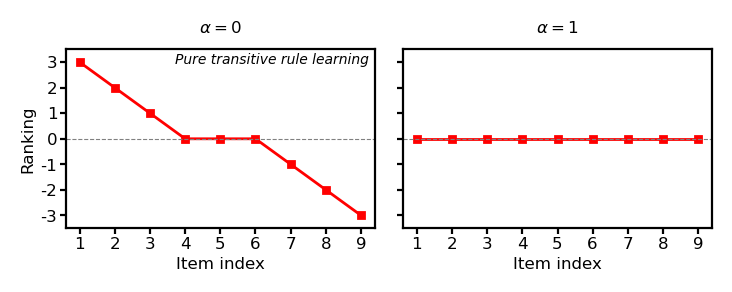

In [ ]:
import contextlib, io


n     = 9
p     = 6
q     = 4

k_s   = 1.0
k_d   = 0.0
c_reg = 1e10

eps          = 1e-10
alphas       = [0, 1 - eps]
panel_labels = [r'$\alpha = 0$', r'$\alpha = 1$']
           

x = np.arange(1, n + 1)

with plt.rc_context({'figure.dpi': 200}):
    fig, axes = plt.subplots(1, 2, figsize=(3.6, 1.4), sharey=True)

    for ax, a, lbl in zip(axes, alphas, panel_labels):
        k_o_a = ((1 - a) / 2) * (k_s - k_d)
        with contextlib.redirect_stdout(io.StringIO()):
            sim_a = Ranking_exp(n=n, k_o=k_o_a, k_s=k_s, k_d=k_d,
                                p=p, q=q, c_reg=c_reg)
        r = sim_a.calc_rank_analytic()
        ax.plot(x, r, marker='s', markersize=2, lw=1.0, color='red')
        ax.axhline(0, color='gray', lw=0.4, ls='--')
        ax.set_xticks(x)
        ax.set_xticklabels([str(k) for k in x], fontsize=6)
        ax.set_ylim(-3.5, 3.5)
        ax.set_yticks(np.arange(-3, 4, 1))
        ax.set_yticklabels([str(k) for k in np.arange(-3, 4, 1)], fontsize=6)
        ax.set_xlabel('Item index', fontsize=6, labelpad=2)
        ax.set_title(lbl, fontsize=6)
        ax.tick_params(axis='both', length=2, pad=1, labelsize=6)

    axes[0].set_ylabel('Ranking', fontsize=6, labelpad=2)
    axes[0].text(0.98, 0.98, 'Pure transitive rule learning', transform=axes[0].transAxes,
                 fontsize=5, ha='right', va='top', style='italic')
            
    plt.tight_layout(pad=0.5, w_pad=0.8)
    plt.show()